1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

2. Load Dataset (RAW LAYER)

In [2]:
df = pd.read_csv("../data/raw/superstore.csv", encoding="latin1")

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


3. Data Understanding (MUST FOR REPORT)

In [3]:
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

,Row ID,Postal Code,Sales
count,9800.000000,9789.000000,9800.000000
mean,4900.500000,55273.322403,230.769059
std,2829.160653,32041.223413,626.651875
min,1.000000,1040.000000,0.444000
25%,2450.750000,23223.000000,17.248000
50%,4900.500000,58103.000000,54.490000
75%,7350.250000,90008.000000,210.605000
max,9800.000000,99301.000000,22638.480000


4. Missing Values Analysis

In [4]:
df.isnull().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64

5. Convert Date Column

In [5]:
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)
df['Ship Date'] = pd.to_datetime(df['Ship Date'], dayfirst=True)

6. Basic Business KPIs

In [6]:
#Total Sales
total_sales = df['Sales'].sum()
print("Total Sales:", total_sales)

Total Sales: 2261536.7827000003


In [7]:
#Estimated Profit
import numpy as np

df['Estimated_Profit'] = df['Sales'] * np.random.uniform(0.1, 0.3, len(df))
df['Estimated_Profit'].sum()

445923.0651024091

In [8]:
#Profit by Category
df.groupby('Category')['Estimated_Profit'].sum()

Category
Furniture          145247.383131
Office Supplies    140529.319233
Technology         160146.362738
Name: Estimated_Profit, dtype: float64

In [9]:
#Profit by Region
df.groupby('Region')['Estimated_Profit'].sum()

Region
Central     97434.316504
East       132483.409570
South       77592.233213
West       138413.105816
Name: Estimated_Profit, dtype: float64

In [10]:
#Total Orders
total_orders = df['Order ID'].nunique()
print("Total Orders:", total_orders)

Total Orders: 4922


In [11]:
#Total Customers
total_customers = df['Customer ID'].nunique()
print("Total Customers:", total_customers)

Total Customers: 793


In [12]:
#Sales by Region
df.groupby('Region')['Sales'].sum().sort_values(ascending=False)

Region
West       710219.6845
East       669518.7260
Central    492646.9132
South      389151.4590
Name: Sales, dtype: float64

In [13]:
#Sales by Category
df.groupby('Category')['Sales'].sum().sort_values(ascending=False)

Category
Technology         827455.8730
Furniture          728658.5757
Office Supplies    705422.3340
Name: Sales, dtype: float64

7. Sales Trend (Time Series Insight)

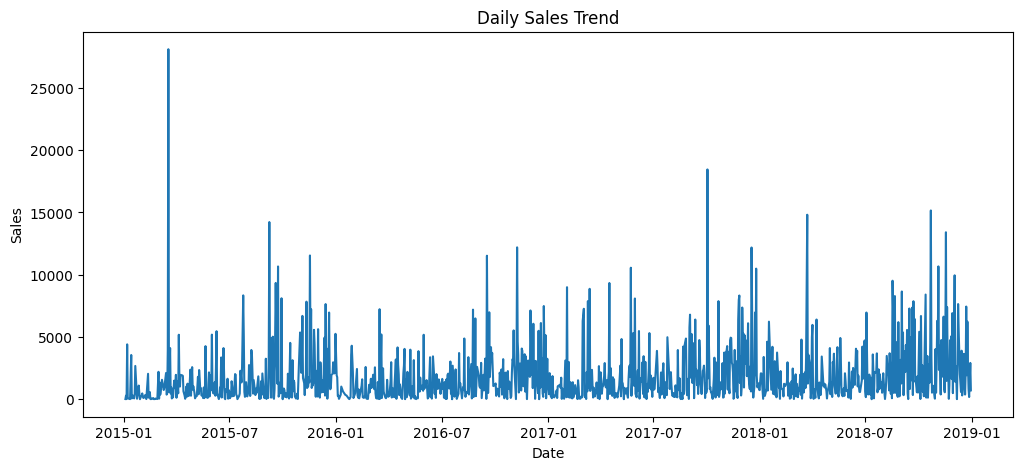

In [14]:
daily_sales = df.groupby('Order Date')['Sales'].sum()

plt.figure(figsize=(12,5))
plt.plot(daily_sales)
plt.title("Daily Sales Trend")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()

8. Category Performance

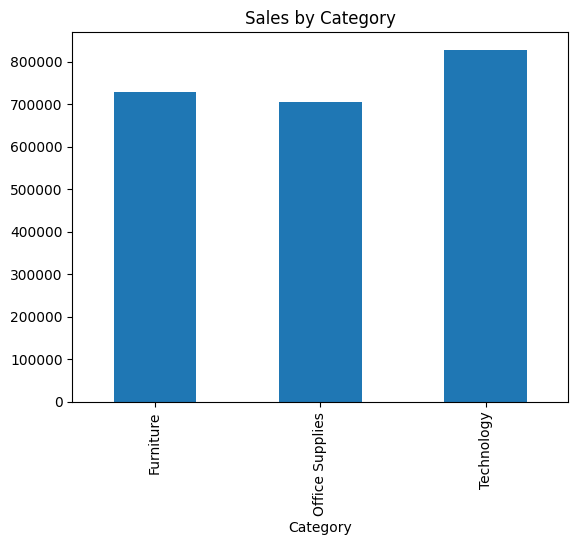

In [15]:
df.groupby('Category')['Sales'].sum().plot(kind='bar')

plt.title("Sales by Category")
plt.show()

9. Region Analysis

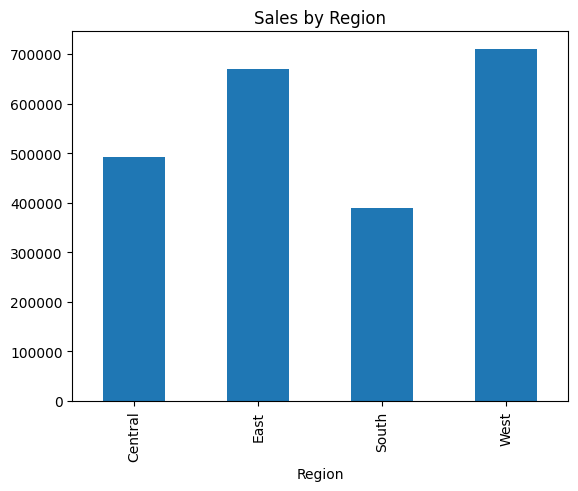

In [16]:
df.groupby('Region')['Sales'].sum().plot(kind='bar')

plt.title("Sales by Region")
plt.show()

10. Profit vs Discount Relationship

In [17]:
df['Discount'] = np.random.choice([0,0.05,0.1,0.15,0.2,0.25], len(df))

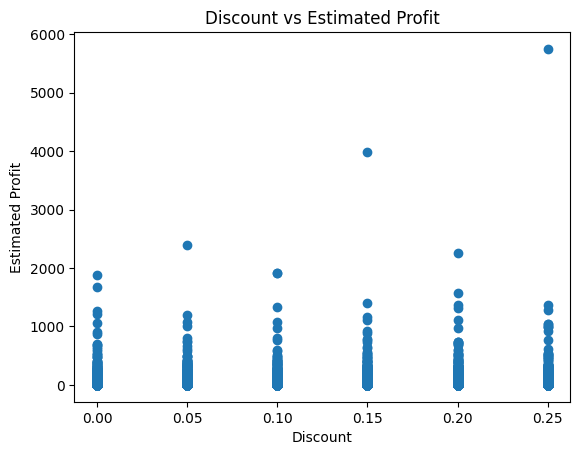

In [18]:
plt.scatter(df['Discount'], df['Estimated_Profit'])
plt.title("Discount vs Estimated Profit")
plt.xlabel("Discount")
plt.ylabel("Estimated Profit")
plt.show()